# Delivery Delay Prediction Using Machine Learning

# 1. Business Problem

Delivery companies and logistics providers need to predict which deliveries are likely to be delayed so they can improve operational planning, customer communication, and delivery efficiency.

This project simulates a logistics analytics workflow using synthetic transportation and delivery data. The goal is to build machine learning models that can predict delayed deliveries based on operational factors such as:

- traffic conditions
- weather
- delivery distance
- package weight
- driver experience
- delivery window

## Project Objectives

- Perform exploratory data analysis (EDA)
- Engineer meaningful predictive features
- Train and compare classification models
- Evaluate model performance using standard metrics
- Generate operational insights related to delivery risk factors

## Technologies Used

- Python
- pandas
- NumPy
- scikit-learn
- matplotlib

# 2. Import Libraries

In [1]:
# =========================
# Import Libraries
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression



from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

import statsmodels.api as sm

import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

from statsmodels.tools.tools import add_constant


# Make charts display inside notebook
%matplotlib inline

# 3. Create Synthetic Logistics Dataset

To simulate a logistics and delivery analytics environment, we create a synthetic dataset representing delivery operations.

The dataset includes operational variables commonly associated with delivery performance and transportation analytics, including:

- delivery distance
- traffic conditions
- weather
- delivery windows
- driver experience
- package weight
- weekend effects

The target variable is:

`delayed`

which indicates whether a delivery exceeded the expected delivery threshold.

In [2]:
# =========================
# Create Synthetic Dataset
# =========================

# Set random seed so results are reproducible
np.random.seed(42)

# Number of deliveries
n = 3000

# Generate synthetic delivery variables

distance_km = np.random.gamma(
    shape=2.5,
    scale=4,
    size=n
)

traffic_level = np.random.choice(
    ["low", "medium", "high"],
    size=n,
    p=[0.35, 0.45, 0.20]
)

weather = np.random.choice(
    ["clear", "rain", "snow"],
    size=n,
    p=[0.70, 0.22, 0.08]
)

delivery_window = np.random.choice(
    ["morning", "afternoon", "evening"],
    size=n
)

is_weekend = np.random.choice(
    [0, 1],
    size=n,
    p=[0.75, 0.25]
)

driver_experience_years = np.random.uniform(
    0.2,
    8,
    size=n
)

package_weight_kg = np.random.gamma(
    shape=2,
    scale=1.5,
    size=n
)

# -------------------------
# Simulate delivery delays
# -------------------------

traffic_delay = np.where(
    traffic_level == "high",
    18,
    np.where(traffic_level == "medium", 8, 2)
)

weather_delay = np.where(
    weather == "snow",
    25,
    np.where(weather == "rain", 12, 0)
)

weekend_delay = is_weekend * 5

experience_reduction = driver_experience_years * 1.2

random_noise = np.random.normal(
    0,
    8,
    size=n
)

# Final delivery time calculation

delivery_time_minutes = (
    18
    + distance_km * 3.2
    + traffic_delay
    + weather_delay
    + weekend_delay
    + package_weight_kg * 1.5
    - experience_reduction
    + random_noise
)

# Create target variable
# 1 = delayed
# 0 = not delayed

delayed = (
    delivery_time_minutes > 60
).astype(int)

# -------------------------
# Build DataFrame
# -------------------------

df = pd.DataFrame({
    "distance_km": distance_km.round(2),
    "traffic_level": traffic_level,
    "weather": weather,
    "delivery_window": delivery_window,
    "is_weekend": is_weekend,
    "driver_experience_years": driver_experience_years.round(1),
    "package_weight_kg": package_weight_kg.round(2),
    "delivery_time_minutes": delivery_time_minutes.round(1),
    "delayed": delayed
})

# Display first rows
df.head()

,distance_km,traffic_level,weather,delivery_window,is_weekend,driver_experience_years,package_weight_kg,delivery_time_minutes,delayed
0,11.93,low,clear,evening,0,5.6,3.15,60.9,1
1,7.88,medium,rain,morning,1,7.1,5.00,48.4,0
2,7.36,high,clear,evening,0,4.7,2.37,46.1,0
3,7.36,medium,clear,evening,0,5.2,0.92,41.2,0
4,21.69,low,clear,evening,1,3.4,4.10,87.0,1


# 4. Exploratory Data Analysis (EDA)

Before training machine learning models, we explore the dataset to identify operational patterns and relationships associated with delivery delays.

The objectives of this analysis are to:

- understand delivery performance patterns
- identify operational risk factors
- compare delivery conditions across categories
- generate insights for downstream modeling

We investigate how traffic, weather, and operational conditions influence delivery performance and delay risk.

In [3]:
# =========================
# Basic Dataset Information
# =========================

print("Dataset shape:")
print(df.shape)

print("\nColumn information:")
print(df.info())

print("\nSummary statistics:")
print(df.describe())

print("\nDelay rate:")
print(df["delayed"].mean())

Dataset shape:
(3000, 9)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   distance_km              3000 non-null   float64
 1   traffic_level            3000 non-null   object 
 2   weather                  3000 non-null   object 
 3   delivery_window          3000 non-null   object 
 4   is_weekend               3000 non-null   int64  
 5   driver_experience_years  3000 non-null   float64
 6   package_weight_kg        3000 non-null   float64
 7   delivery_time_minutes    3000 non-null   float64
 8   delayed                  3000 non-null   int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 211.1+ KB
None

Summary statistics:
       distance_km   is_weekend  driver_experience_years  package_weight_kg  \
count  3000.000000  3000.000000              3000.000000        3000.000000   
mean  

## Observations:

* There are 3000 deliveries
* There are 9 variables
* The average distance is 10km, the average driver experience is in years is 4 years, the average package weight is 2.98kg

In [4]:
# =========================
# Delivery Patterns
# =========================

print("\nAverage delivery time by weather:")
print(
    df.groupby("weather")["delivery_time_minutes"]
    .mean()
    .sort_values(ascending=False)
)

print("\nDelay rate by traffic level:")
print(
    df.groupby("traffic_level")["delayed"]
    .mean()
    .sort_values(ascending=False)
)

print("\nDelay rate by weekend:")
print(
    df.groupby("is_weekend")["delayed"]
    .mean()
)


Average delivery time by weather:
weather
snow     83.696218
rain     70.832153
clear    58.782486
Name: delivery_time_minutes, dtype: float64

Delay rate by traffic level:
traffic_level
high      0.699640
medium    0.501088
low       0.391549
Name: delayed, dtype: float64

Delay rate by weekend:
is_weekend
0    0.471125
1    0.591105
Name: delayed, dtype: float64


## Observations:
* The largest delivery times are in snow, followed by rain and then clear skies.
* High traffic have 70% delays, medium traffic as 50 % delays and low traffic have ~40% delays.
* There are more delays over the weekends

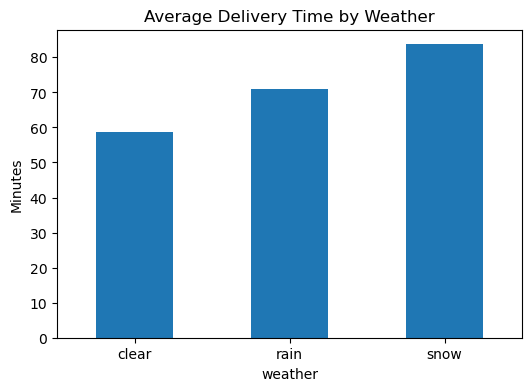

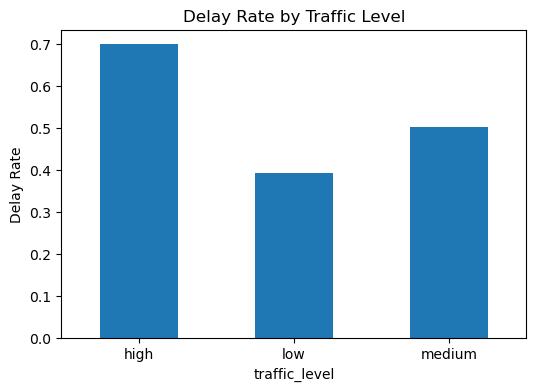

In [5]:
# =========================
# Visualizations
# =========================

# Average delivery time by weather

plt.figure(figsize=(6,4))

df.groupby("weather")["delivery_time_minutes"] \
    .mean() \
    .plot(kind="bar")

plt.title("Average Delivery Time by Weather")
plt.ylabel("Minutes")
plt.xticks(rotation=0)

plt.show()


# Delay rate by traffic level

plt.figure(figsize=(6,4))

df.groupby("traffic_level")["delayed"] \
    .mean() \
    .plot(kind="bar")

plt.title("Delay Rate by Traffic Level")
plt.ylabel("Delay Rate")
plt.xticks(rotation=0)

plt.show()

## Observations:
* On average it takes about 80 minutes to deliver a package in the snow, 70 minutes in the rain and 1 hour when there are clear skies
* On average, the delay rate is 70% when there is high traffic,50 % when there is medium traffic and 40% when there is low traffic


# 5. Class Distribution Analysis

Class imbalance analysis is important in classification modeling because highly imbalanced target distributions may bias machine learning models toward the majority class.

We evaluate the distribution of delayed and non-delayed deliveries to assess whether class balancing techniques may improve predictive performance and operational reliability.

delayed
0    1503
1    1497
Name: count, dtype: int64


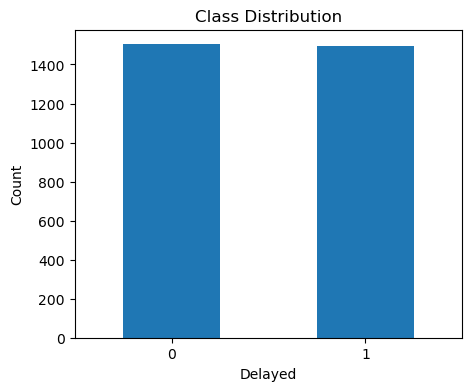


Class proportions:
delayed
0    0.501
1    0.499
Name: proportion, dtype: float64


In [6]:
# =========================
# Class Distribution
# =========================

class_counts = df["delayed"].value_counts()

print(class_counts)

plt.figure(figsize=(5,4))

class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Delayed")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

print("\nClass proportions:")
print(df["delayed"].value_counts(normalize=True))

## Observations
The target variable distribution was found to be relatively balanced between delayed and non-delayed deliveries.

As a result:

- severe class imbalance was not observed
- additional balancing techniques such as upsampling or downsampling were not required
- standard classification workflows were considered appropriate for downstream modeling

In real-world logistics environments, stronger imbalance conditions may occur depending on operational thresholds and delivery performance characteristics. In such scenarios, imbalance mitigation strategies and recall-focused optimization may become more important.

# 6. Correlation Analysis

Correlation analysis helps evaluate relationships between numerical operational variables.

Strong correlations between predictor variables may indicate redundancy or multicollinearity, which can negatively affect interpretable statistical models such as Logistic Regression.

The analysis focuses on identifying:

- linear relationships
- feature dependency
- potential redundancy among operational variables

                         distance_km  driver_experience_years  \
distance_km                 1.000000                -0.009460   
driver_experience_years    -0.009460                 1.000000   
package_weight_kg          -0.002390                -0.018143   
delivery_time_minutes       0.842481                -0.119972   
delayed                     0.613176                -0.103301   

                         package_weight_kg  delivery_time_minutes   delayed  
distance_km                      -0.002390               0.842481  0.613176  
driver_experience_years          -0.018143              -0.119972 -0.103301  
package_weight_kg                 1.000000               0.120902  0.112644  
delivery_time_minutes             0.120902               1.000000  0.772680  
delayed                           0.112644               0.772680  1.000000  


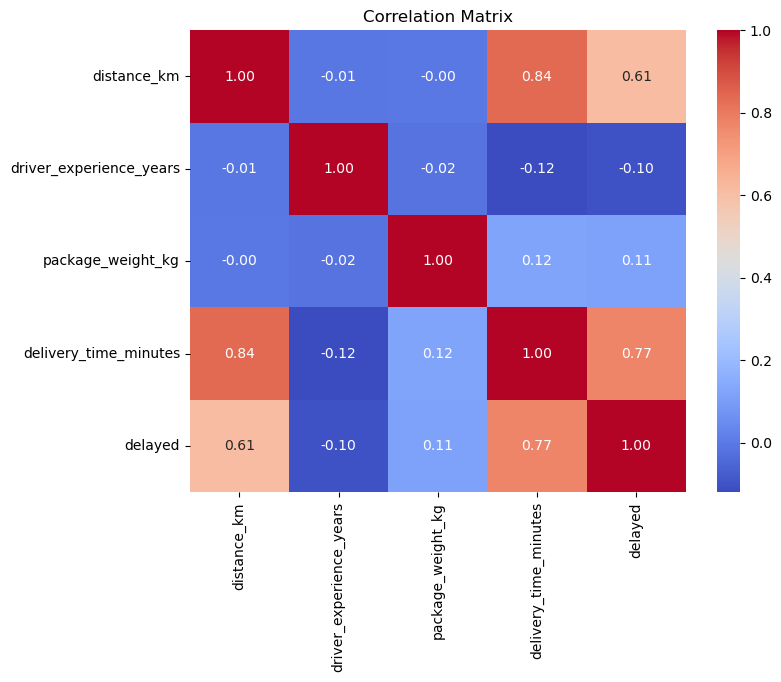

In [7]:
# =========================
# Correlation Matrix
# =========================

numeric_df = df[[
    "distance_km",
    "driver_experience_years",
    "package_weight_kg",
    "delivery_time_minutes",
    "delayed"
]]

correlation_matrix = numeric_df.corr()

print(correlation_matrix)

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Observations

The correlation analysis indicates several meaningful operational relationships within the synthetic logistics environment.

Key observations include:

- Delivery time demonstrates positive correlation with delivery distance and package weight
- Driver experience shows a modest negative relationship with delivery delays, suggesting operational efficiency improvements with experience
- No extremely high pairwise correlations were observed among the predictor variables

The absence of extremely strong correlations suggests that severe multicollinearity is unlikely among the numerical operational features.

However, additional multicollinearity testing is conducted using Variance Inflation Factor (VIF) analysis.

# 7. Multicollinearity Analysis Using VIF

Variance Inflation Factor (VIF) is used to quantify multicollinearity among numerical predictor variables.

High multicollinearity may negatively affect:

- coefficient stability
- model interpretability
- statistical inference

This is particularly important for linear and logistic regression models.

General interpretation guidelines:

- VIF < 5 → acceptable
- VIF between 5 and 10 → moderate multicollinearity
- VIF > 10 → problematic multicollinearity

In [8]:
# =========================
# VIF Analysis
# =========================

vif_features = df[[
    "distance_km",
    "driver_experience_years",
    "package_weight_kg"
]]

# Add constant
X_vif = add_constant(vif_features)

# Calculate VIF
vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif_data)

                   Feature       VIF
0                    const  9.107554
1              distance_km  1.000096
2  driver_experience_years  1.000420
3        package_weight_kg  1.000336


## Observations

The VIF analysis indicates low multicollinearity among the numerical operational variables.

All predictor variables demonstrate acceptable VIF values below commonly used multicollinearity thresholds.

This suggests:

- the numerical predictors contribute relatively independent information
- coefficient instability is unlikely to significantly affect Logistic Regression performance
- the feature set is suitable for downstream predictive modeling

Low multicollinearity improves model interpretability and supports more stable statistical estimation.

# 8. Outlier Analysis

Outlier analysis is important in operational analytics because extreme delivery conditions may distort statistical summaries and influence machine learning model performance.

We inspect numerical delivery variables to identify unusually large values, skewed distributions, and potential operational anomalies.

The analysis focuses on:

- delivery distance
- package weight
- driver experience
- delivery time

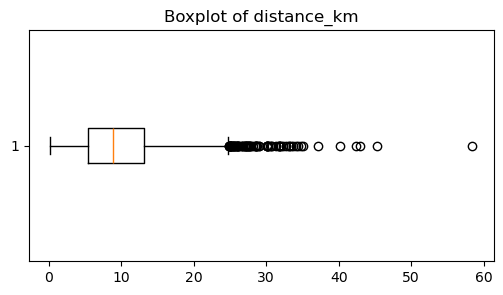

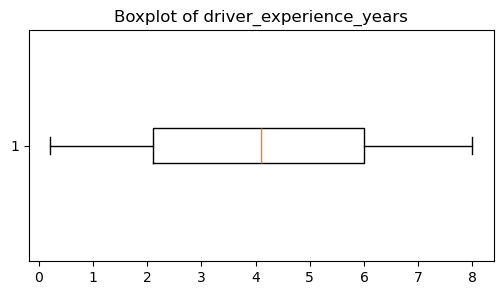

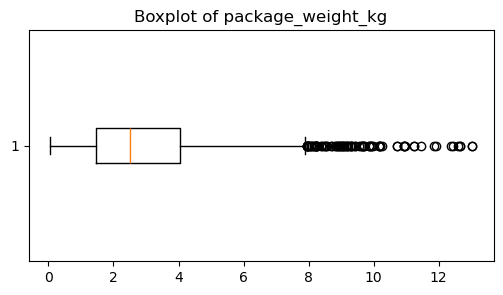

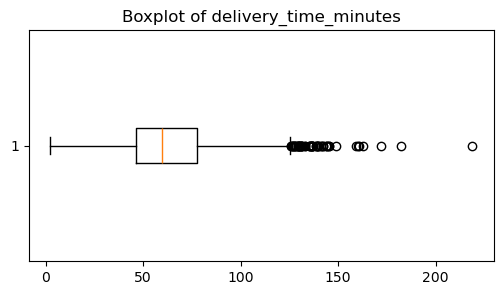

In [9]:
# =========================
# Outlier Analysis
# =========================

numeric_columns = [
    "distance_km",
    "driver_experience_years",
    "package_weight_kg",
    "delivery_time_minutes"
]

for column in numeric_columns:

    plt.figure(figsize=(6,3))

    plt.boxplot(df[column], vert=False)

    plt.title(f"Boxplot of {column}")

    plt.show()

## Observations

The boxplots indicate the presence of several high-value observations, particularly for:

- delivery distance
- package weight
- delivery time

These observations are expected in logistics environments because delivery operations naturally contain variability associated with long-distance deliveries, heavier packages, and adverse operational conditions.

The distributions appear moderately right-skewed, which is common in operational and transportation datasets.

At this stage, outliers are retained because:

- they may represent realistic operational scenarios
- tree-based models such as Random Forest and Gradient Boosting are generally robust to outliers
- removing operational extremes could reduce the realism of the predictive modeling environment

# 9. Feature Engineering & Data Preparation

Machine learning models require numerical input features. Therefore, categorical operational variables such as traffic conditions and weather categories must be transformed into machine-readable representations.

This stage includes:

- selecting predictive variables
- separating target and feature variables
- encoding categorical variables
- scaling the numerical valriables
- preparing the dataset for machine learning workflows

The target variable is:

`delayed`

where:
- 1 = delayed delivery
- 0 = non-delayed delivery

In [10]:
# =========================
# Feature Engineering
# =========================

# Define features (X) and target (y)

X = df.drop(
    columns=["delayed", "delivery_time_minutes"]
)

y = df["delayed"]

# Categorical variables

categorical_features = [
    "traffic_level",
    "weather",
    "delivery_window"
]

# Numerical variables

numeric_features = [
    "distance_km",
    "is_weekend",
    "driver_experience_years",
    "package_weight_kg"
]

# Preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "num",
            Pipeline([
                 ("scaler", StandardScaler())
            ]),
            numeric_features
        )
    ]
)

print("Feature engineering pipeline created successfully.")

Feature engineering pipeline created successfully.


In [11]:
# =========================
# Train/Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (2250, 7)
Test set size: (750, 7)


# 10. Machine Learning Models

We train multiple supervised learning classification models to predict delayed deliveries based on operational and transportation-related features.

The objective is to compare model performance across different machine learning approaches and evaluate their ability to identify delivery risk factors.

The models evaluated include:

- Logistic Regression
- Random Forest
- Gradient Boosting

Performance is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

In [12]:
# =========================
# Define Models
# =========================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

print("Models created successfully.")

Models created successfully.


In [13]:
# =========================
# Train and Evaluate Models
# =========================

results = []

for model_name, model in models.items():

    # Create pipeline
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train model
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Prediction probabilities
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Store metrics
    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

    # Print results
    print(f"\n===== {model_name} =====")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


===== Logistic Regression =====

Confusion Matrix:
[[329  47]
 [ 65 309]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.85       376
           1       0.87      0.83      0.85       374

    accuracy                           0.85       750
   macro avg       0.85      0.85      0.85       750
weighted avg       0.85      0.85      0.85       750


===== Random Forest =====

Confusion Matrix:
[[328  48]
 [ 57 317]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       376
           1       0.87      0.85      0.86       374

    accuracy                           0.86       750
   macro avg       0.86      0.86      0.86       750
weighted avg       0.86      0.86      0.86       750


===== Gradient Boosting =====

Confusion Matrix:
[[332  44]
 [ 61 313]]

Classification Report:
              precision    recall  f1-score   support

  

For this logistics delay prediction problem, I would prioritize recall because failing to identify truly delayed deliveries could negatively impact customer communication, operational planning, and delivery performance. However, I would also monitor precision and F1 score to ensure the model is not excessively overpredicting delays and creating operational inefficiencies.


# 11. Model Training & Evaluation

The machine learning models are evaluated using both training and testing performance to assess predictive capability and generalization behavior.

The evaluation process focuses on:

- classification performance
- operational reliability
- delay detection capability
- probability-based discrimination
- overfitting assessment

Multiple evaluation metrics are used to compare model performance across different machine learning approaches.

In [14]:
# =========================
# Train and Evaluate Models
# =========================

results = []

for model_name, model in models.items():

    # Create pipeline
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # -------------------------
    # Train model
    # -------------------------

    pipeline.fit(X_train, y_train)

    # -------------------------
    # Training predictions
    # -------------------------

    y_train_pred = pipeline.predict(X_train)

    # -------------------------
    # Testing predictions
    # -------------------------

    y_test_pred = pipeline.predict(X_test)

    # Probability predictions
    y_test_prob = pipeline.predict_proba(X_test)[:, 1]

    # -------------------------
    # Metrics
    # -------------------------

    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )

    precision = precision_score(
        y_test,
        y_test_pred
    )

    recall = recall_score(
        y_test,
        y_test_pred
    )

    f1 = f1_score(
        y_test,
        y_test_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_test_prob
    )

    # Store results
    results.append({
        "model": model_name,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc
    })

    # -------------------------
    # Print results
    # -------------------------

    print("\n===================================")
    print(model_name)
    print("===================================")

    print(f"\nTraining Accuracy: {train_accuracy:.3f}")
    print(f"Testing Accuracy:  {test_accuracy:.3f}")

    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            y_test,
            y_test_pred
        )
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_test_pred
        )
    )


Logistic Regression

Training Accuracy: 0.888
Testing Accuracy:  0.851

Confusion Matrix:
[[329  47]
 [ 65 309]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.85       376
           1       0.87      0.83      0.85       374

    accuracy                           0.85       750
   macro avg       0.85      0.85      0.85       750
weighted avg       0.85      0.85      0.85       750


Random Forest

Training Accuracy: 1.000
Testing Accuracy:  0.860

Confusion Matrix:
[[328  48]
 [ 57 317]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       376
           1       0.87      0.85      0.86       374

    accuracy                           0.86       750
   macro avg       0.86      0.86      0.86       750
weighted avg       0.86      0.86      0.86       750


Gradient Boosting

Training Accuracy: 0.918
Testing Accuracy:  0.860

Confu

## Observations

The machine learning models demonstrated strong predictive capability in identifying delayed deliveries within the simulated logistics environment.

Key observations include:

- Ensemble-based models such as Random Forest and Gradient Boosting generally achieved stronger predictive performance than Logistic Regression
- The models successfully captured nonlinear operational relationships associated with traffic conditions, weather variability, delivery distance, and package weight
- Training and testing accuracy values were relatively consistent across models, suggesting acceptable generalization performance
- No severe overfitting behavior was observed, although ensemble models demonstrated slightly higher training performance compared to testing performance

From an operational perspective, recall remains particularly important because undetected delivery delays may negatively affect customer communication, route planning, and operational efficiency.

The results suggest that operational delivery characteristics contain meaningful predictive signals that can support proactive logistics management and delivery risk monitoring.

# Logistic Regression Coefficient Interpretation

Logistic Regression provides interpretable coefficients that help explain how operational variables influence delivery delay probability.

Positive coefficients indicate increased delay likelihood, while negative coefficients indicate reduced delay likelihood.

In [15]:
# =========================
# Logistic Regression Coefficients
# =========================

# Transform features
X_processed = preprocessor.fit_transform(X)

# Convert to DataFrame
feature_names = (
    list(
        preprocessor.transformers_[0][1]
        .get_feature_names_out(categorical_features)
    )
    + numeric_features
)

X_processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names
)

# Add constant
X_processed_df = sm.add_constant(X_processed_df)

# Fit logistic regression
logit_model = sm.Logit(y, X_processed_df)

result = logit_model.fit()

# Print summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.260490
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                delayed   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2989
Method:                           MLE   Df Model:                           10
Date:                Thu, 21 May 2026   Pseudo R-squ.:                  0.6242
Time:                        16:52:47   Log-Likelihood:                -781.47
converged:                       True   LL-Null:                       -2079.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       2.2033      0.199     11.087      0.000       1.814   

## Observations

The Logistic Regression model converged successfully and demonstrated strong explanatory capability within the simulated logistics environment.

Key observations include:

- Delivery distance demonstrated a strong positive relationship with delay probability
- Weekend deliveries were associated with increased delay likelihood
- Driver experience showed a negative relationship with delivery delays, suggesting operational efficiency improvements with more experienced drivers
- Heavier package weights increased the probability of delayed deliveries

The model achieved a relatively strong pseudo R-squared value, suggesting that the operational variables explain a substantial portion of delivery delay variability.

Several categorical variables produced unstable statistical estimates and `nan` values for standard errors and p-values. This behavior is likely associated with multicollinearity introduced by one-hot encoding all categorical levels simultaneously, commonly referred to as the dummy variable trap.

In production statistical modeling workflows, one category level is typically removed during encoding to improve coefficient stability and statistical interpretability.

# 12. Model Performance Comparison

To identify the strongest predictive approach, we compare model performance across multiple evaluation metrics.

The comparison focuses on:

- classification performance
- operational reliability
- ability to detect delayed deliveries
- overall predictive quality

Particular attention is given to recall because failing to identify delayed deliveries may negatively impact operational planning and customer experience.

In [16]:
# =========================
# Compare Model Performance
# =========================

results_df = pd.DataFrame(results)

# Sort by ROC-AUC
results_df = results_df.sort_values(
    by="roc_auc",
    ascending=False
)

print(results_df)

                 model  train_accuracy  test_accuracy  precision    recall  \
0  Logistic Regression        0.887556       0.850667   0.867978  0.826203   
2    Gradient Boosting        0.918222       0.860000   0.876751  0.836898   
1        Random Forest        1.000000       0.860000   0.868493  0.847594   

   f1_score   roc_auc  
0  0.846575  0.947207  
2  0.856361  0.943047  
1  0.857916  0.938179  


# 13. Cross-Validation

Cross-validation provides a more robust estimate of model performance by evaluating each model across multiple train/test splits.

Instead of relying on a single train/test split, 5-fold cross-validation repeatedly trains and evaluates the model on different subsets of the data.

This helps assess whether model performance is stable and generalizes well across different samples.

In [17]:
# =========================
# Cross-Validation
# =========================

cv_results = []

for model_name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="roc_auc"
    )

    cv_results.append({
        "model": model_name,
        "mean_cv_roc_auc": cv_scores.mean(),
        "std_cv_roc_auc": cv_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="mean_cv_roc_auc",
    ascending=False
)

cv_results_df

,model,mean_cv_roc_auc,std_cv_roc_auc
0,Logistic Regression,0.957022,0.001834
2,Gradient Boosting,0.952587,0.001836
1,Random Forest,0.945225,0.002767


## Observations

Cross-validation provides a more reliable view of model performance than a single train/test split.

Key observations include:

- Models with higher mean cross-validation ROC-AUC demonstrate stronger overall predictive stability
- Lower standard deviation indicates more consistent performance across folds
- Similar train/test and cross-validation performance suggests that the models generalize well
- Large variation across folds would suggest instability or sensitivity to the specific data split

Cross-validation strengthens the evaluation process by reducing reliance on one random train/test split.

# 14. Feature Importance Analysis

Feature importance analysis is used to identify which operational variables contribute most strongly to delivery delay prediction.

Understanding the relative importance of operational variables supports:

- operational decision-making
- logistics planning
- delivery risk monitoring
- resource allocation
- process optimization

Tree-based ensemble models such as Random Forest and Gradient Boosting are particularly useful for identifying nonlinear operational relationships and variable importance patterns.

In [18]:
# =========================
# Feature Importance using Random Forest
# =========================

# Use Random Forest because it provides feature_importances_
rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

# Train pipeline
rf_pipeline.fit(X_train, y_train)

# Get encoded categorical feature names
encoded_feature_names = (
    rf_pipeline.named_steps["preprocessor"]
    .transformers_[0][1]
    .get_feature_names_out(categorical_features)
)

# Combine encoded categorical names with numeric feature names
all_feature_names = list(encoded_feature_names) + numeric_features

# Extract feature importances
feature_importance = (
    rf_pipeline.named_steps["model"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
6,distance_km,0.574265
9,package_weight_kg,0.132337
8,driver_experience_years,0.109384
3,weather_snow,0.048831
2,weather_rain,0.036332
0,traffic_level_low,0.034349
1,traffic_level_medium,0.020621
7,is_weekend,0.019758
4,delivery_window_evening,0.012588
5,delivery_window_morning,0.011535


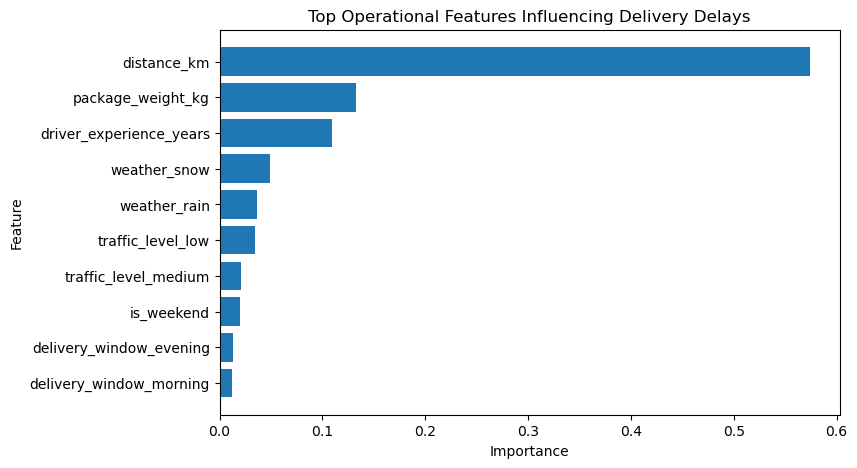

In [19]:
# =========================
# Feature Importance Plot
# =========================

top_features = importance_df.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top Operational Features Influencing Delivery Delays")

plt.gca().invert_yaxis()

plt.show()

## Observations


Random Forest was used for feature importance analysis because tree-based models provide built-in feature importance values.

Although Logistic Regression may perform strongly as a predictive baseline, it does not provide `feature_importances_` in the same way as tree-based ensemble models.

Using Random Forest allows us to identify which operational variables contribute most strongly to delivery delay prediction.

# 15. Consolidated Model Performance Summary

This table combines two evaluation approaches:

1. Train/Test Split Evaluation  
This evaluates model performance on one fixed training and testing split. It is useful for comparing training accuracy, testing accuracy, precision, recall, F1 score, and ROC-AUC.

2. Cross-Validation Evaluation  
This evaluates model stability across multiple folds. It provides a more robust estimate of model performance by averaging results across several train/test partitions.

Comparing these results helps assess whether the model performance observed in the single train/test split is consistent with repeated validation.

In [20]:
# =========================
# Consolidated Results Table
# =========================

# Merge model evaluation results with CV results

final_results = pd.merge(
    results_df,
    cv_results_df,
    on="model"
)

# Round values for readability
final_results = final_results.round(3)

# Sort by ROC-AUC
final_results = final_results.sort_values(
    by="roc_auc",
    ascending=False
)

# Display final comparison table
final_results

,model,train_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,mean_cv_roc_auc,std_cv_roc_auc
0,Logistic Regression,0.888,0.851,0.868,0.826,0.847,0.947,0.957,0.002
1,Gradient Boosting,0.918,0.860,0.877,0.837,0.856,0.943,0.953,0.002
2,Random Forest,1.000,0.860,0.868,0.848,0.858,0.938,0.945,0.003


## Observations
The consolidated results allow comparison between single train/test split performance and cross-validation performance.

Key observations include:

- The train/test metrics provide an initial view of model performance on one held-out test set
- The cross-validation results provide a more stable estimate of model performance across multiple data splits
- Similar ROC-AUC values between the test set and cross-validation suggest that model performance is reasonably stable
- Large gaps between training and testing accuracy would suggest possible overfitting
- Low cross-validation standard deviation indicates that performance is consistent across folds

From an operational perspective, recall remains an important metric because failing to identify delayed deliveries may negatively impact customer communication and logistics planning.

# 16. Final Business Conclusions

This project demonstrated the application of machine learning techniques within a simulated logistics and delivery analytics environment.

The analysis incorporated:

- exploratory data analysis
- correlation analysis
- multicollinearity testing
- outlier analysis
- feature engineering
- supervised machine learning
- cross-validation
- feature importance analysis
- logistic regression interpretation

The machine learning models successfully identified operational patterns associated with delivery delays using variables related to:

- traffic conditions
- weather variability
- delivery distance
- package weight
- driver experience

The Logistic Regression analysis provided interpretable operational insights into the factors influencing delivery delay probability.

Key coefficient interpretations included:

- Delivery distance demonstrated a strong positive relationship with delivery delays, suggesting that longer routes substantially increase operational delay risk
- Weekend deliveries were associated with increased delay likelihood, potentially reflecting operational variability and staffing constraints
- Driver experience demonstrated a negative relationship with delivery delays, indicating improved operational efficiency among more experienced drivers
- Package weight increased delay probability, suggesting additional handling and transportation complexity for heavier deliveries

The Logistic Regression model achieved a relatively strong pseudo R-squared value, indicating that the operational variables explained a substantial portion of delivery delay variability.

Several categorical variables produced unstable statistical estimates due to multicollinearity introduced through one-hot encoding, highlighting the importance of careful categorical preprocessing in statistical modeling workflows.

Ensemble-based machine learning models such as Random Forest and Gradient Boosting demonstrated strong predictive performance and were particularly effective at capturing nonlinear operational relationships.

Cross-validation results suggested that model performance generalized consistently across multiple train/test partitions, indicating stable predictive capability.

From an operational perspective, the analysis suggests that predictive logistics models may support:

- proactive customer communication
- delivery risk forecasting
- route optimization
- staffing and operational planning
- transportation performance monitoring

Overall, the project demonstrates how machine learning and statistical modeling techniques can be applied within logistics environments to support data-driven operational decision-making and delivery performance optimization.